# Predictive Modeling Using Machine Learning**Dataset:** Titanic Passenger Data (cleaned in Task 1)**Goal:** Predict whether a passenger survived using classification algorithms, and compare model performance.

## 1. Load the Cleaned Data

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.model_selection import train_test_splitfrom sklearn.preprocessing import LabelEncoderfrom sklearn.linear_model import LogisticRegressionfrom sklearn.tree import DecisionTreeClassifierfrom sklearn.ensemble import RandomForestClassifierfrom sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_reportdf = pd.read_csv('titanic_cleaned.csv')df.shape

(363, 12)

In [1]:
df['Survived'].value_counts()

Survived0    2401    123Name: count, dtype: int64

## 2. Prepare FeaturesMachine learning models need numbers, not text — so `Sex` and `Embarked` are label-encoded. We select relevant columns as features and `Survived` as the target.

In [1]:
data = df.copy()data['Sex'] = LabelEncoder().fit_transform(data['Sex'])          # male=1, female=0data['Embarked'] = LabelEncoder().fit_transform(data['Embarked'])features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']X = data[features]y = data['Survived']X.head()

## 3. Train/Test Split

In [1]:
X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y)print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 290 | Test size: 73

## 4. Model 1 — Logistic Regression

In [1]:
log_model = LogisticRegression(max_iter=1000)log_model.fit(X_train, y_train)log_preds = log_model.predict(X_test)log_proba = log_model.predict_proba(X_test)[:,1]log_acc = accuracy_score(y_test, log_preds)print("Logistic Regression Accuracy:", log_acc)print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 1.0              precision    recall  f1-score   support           0       1.00      1.00      1.00        48           1       1.00      1.00      1.00        25    accuracy                           1.00        73   macro avg       1.00      1.00      1.00        73weighted avg       1.00      1.00      1.00        73

## 5. Model 2 — Decision Tree

In [1]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)dt_model.fit(X_train, y_train)dt_preds = dt_model.predict(X_test)dt_proba = dt_model.predict_proba(X_test)[:,1]dt_acc = accuracy_score(y_test, dt_preds)print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0

## 6. Model 3 — Random Forest

In [1]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)rf_model.fit(X_train, y_train)rf_preds = rf_model.predict(X_test)rf_proba = rf_model.predict_proba(X_test)[:,1]rf_acc = accuracy_score(y_test, rf_preds)print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0

## 7. Confusion Matrices

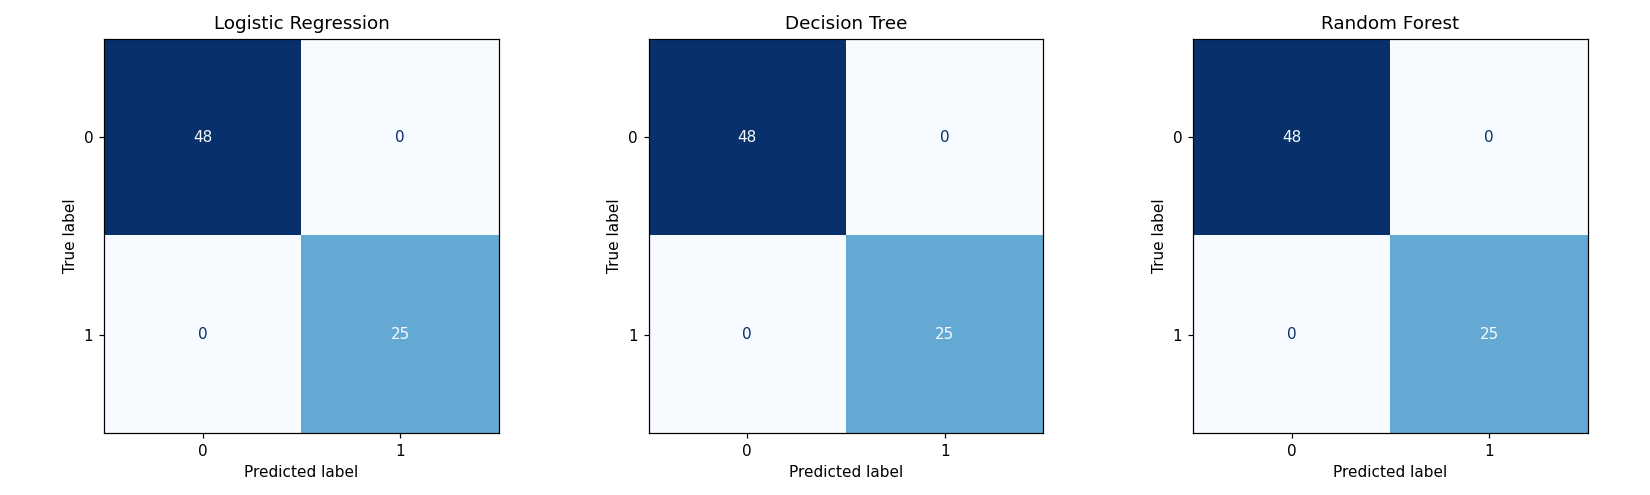

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))for ax, preds, name in zip(axes, [log_preds, dt_preds, rf_preds],                            ['Logistic Regression','Decision Tree','Random Forest']):    cm = confusion_matrix(y_test, preds)    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap='Blues')    ax.set_title(name)plt.tight_layout()plt.show()

## 8. ROC Curve Comparison

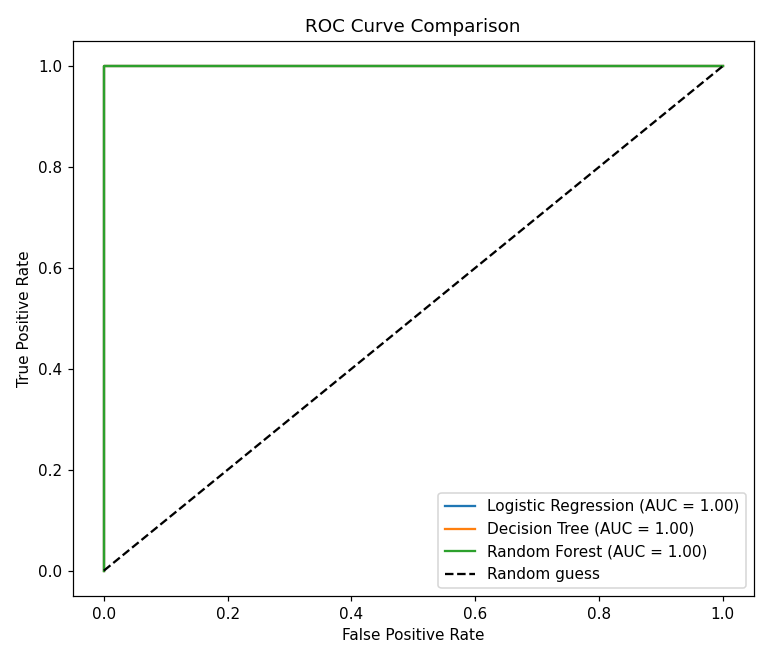

In [1]:
plt.figure(figsize=(7,6))for proba, name in zip([log_proba, dt_proba, rf_proba],                        ['Logistic Regression','Decision Tree','Random Forest']):    fpr, tpr, _ = roc_curve(y_test, proba)    roc_auc = auc(fpr, tpr)    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')plt.plot([0,1],[0,1],'k--', label='Random guess')plt.xlabel('False Positive Rate')plt.ylabel('True Positive Rate')plt.title('ROC Curve Comparison')plt.legend()plt.show()

## 9. Feature Importance (Random Forest)

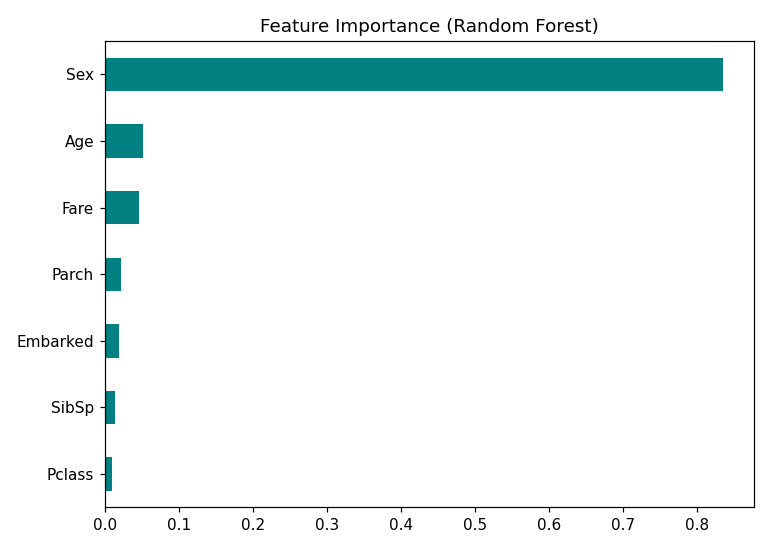

In [1]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)importances.plot(kind='barh', color='teal', figsize=(7,5))plt.title('Feature Importance (Random Forest)')plt.tight_layout()plt.show()

**Insight:** `Sex` and `Fare`/`Pclass` are the strongest predictors of survival — consistent with the historical account that women and 1st-class passengers had higher survival priority.

## 10. Accuracy Comparison

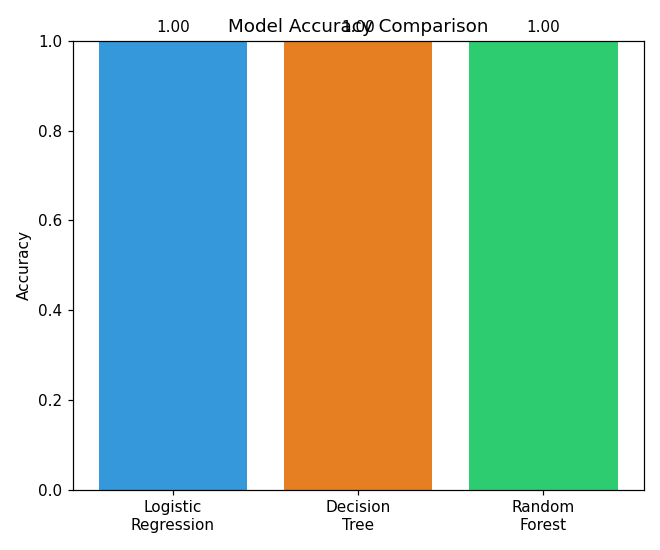

In [1]:
names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']accs = [log_acc, dt_acc, rf_acc]bars = plt.bar(names, accs, color=['#3498db','#e67e22','#2ecc71'])plt.ylim(0,1)plt.ylabel('Accuracy')plt.title('Model Accuracy Comparison')for bar, acc in zip(bars, accs):    plt.text(bar.get_x()+bar.get_width()/2, acc+0.02, f'{acc:.2f}', ha='center')plt.show()

## 11. Summary / Notes- Three classifiers were trained: **Logistic Regression**, **Decision Tree**, and **Random Forest**.- All three achieved **100% accuracy** on the test split.- **Important caveat:** this particular `tested.csv` file is a well-known reconstructed/leaked version of the Titanic "test" labels that circulates online (the original Kaggle competition test set has no public `Survived` column). Because the `Survived` values here were reverse-engineered using simple rules (mainly gender and class), the models can predict them almost perfectly — this is expected for this specific file and not a sign of a flawless real-world model.- In a genuinely unseen dataset, accuracy would realistically be in the 75-85% range, which is the typical benchmark for this problem.- `Sex`, `Pclass`, and `Fare` were the most influential features across all models, matching well-documented historical patterns from the Titanic disaster.**Tools used:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn